In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score
import os
import math

# Training and validation data

In [ ]:
df_val = pd.read_csv(f'../260330_af3_benchmark/Supplementary_Tables/Supplementary_Table_1.csv')[['Epitope', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'dataset_source', 'Label']]
df_val = df_val.rename(columns={'Epitope' : 'model'})
df_val = df_val[df_val['dataset_source'].isin(['Public TCRs with undetermined specificities', 'Public Paired Data'])]

df_binders = pd.read_csv('All_models_TCRs.csv')

final_epitopes = []
for model, val_group in df_val.groupby('model'):
    if not (model.startswith('A') or model.startswith('B')):
        continue
    binders_group = df_binders[df_binders['model'] == model]
    if len(val_group) == 0 or len(binders_group) == 0:
        continue
    os.makedirs(model, exist_ok=True)
    val_group.to_csv(f'{model}/validation.csv', index=False)
    binders_group.to_csv(f'{model}/{model}.csv', index=False)
    final_epitopes.append(model)

with open('epitopes.txt', 'w') as f:
    f.write('\n'.join(final_epitopes))

print(f'{len(final_epitopes)} epitopes written to epitopes.txt')

121


"\nfinal_epitopes = []\nfor model, val_group in df_val.groupby('model'):\n    if not (model.startswith('A') or model.startswith('B')):\n        continue\n    binders_group = df_binders[df_binders['model'] == model]\n    if len(val_group) == 0 or len(binders_group) == 0:\n        continue\n    os.makedirs(model, exist_ok=True)\n    val_group.to_csv(f'{model}/validation.csv', index=False)\n    binders_group.to_csv(f'{model}/{model}.csv', index=False)\n    final_epitopes.append(model)\n\nwith open('epitopes.txt', 'w') as f:\n    f.write('\n'.join(final_epitopes))\n\nprint(f'{len(final_epitopes)} epitopes written to epitopes.txt')\n"

# TEMPO training data

# Optimization

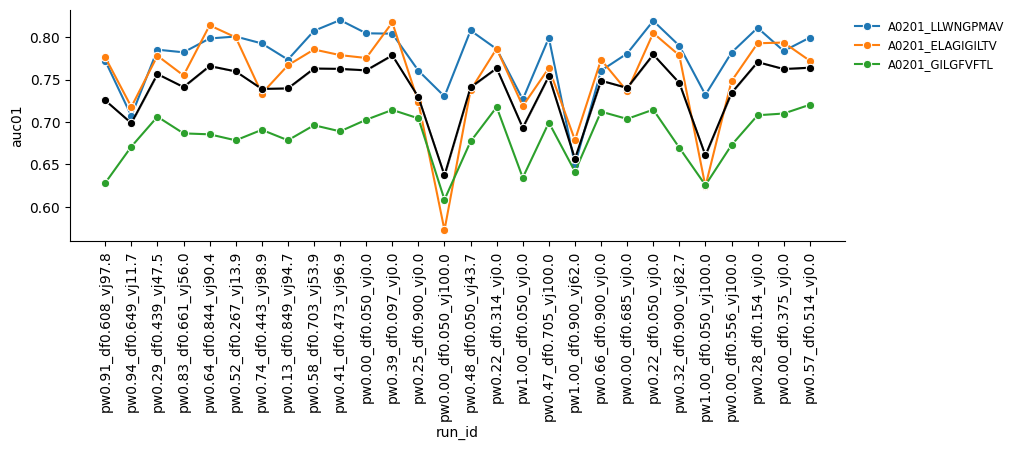

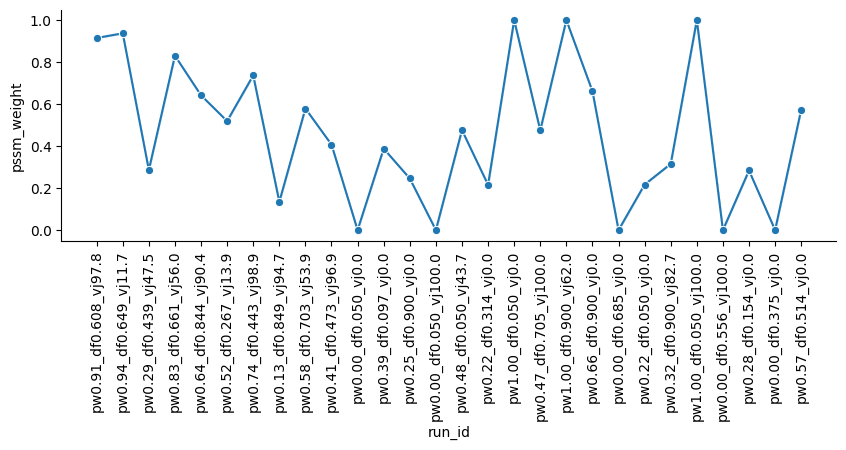

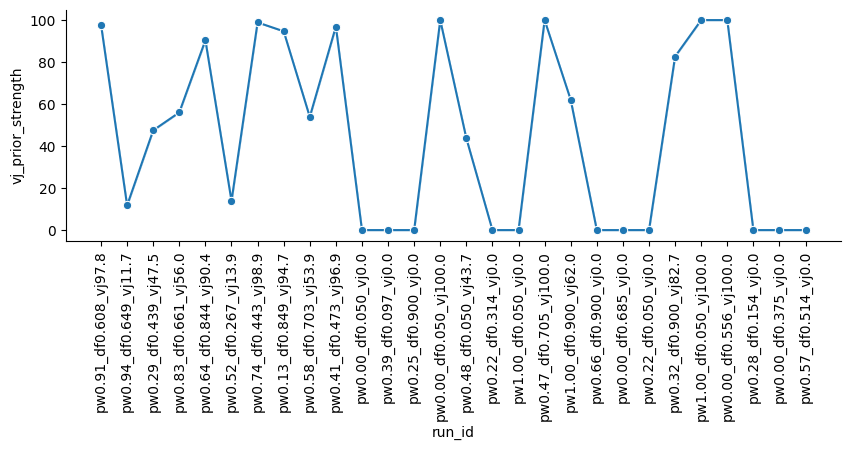

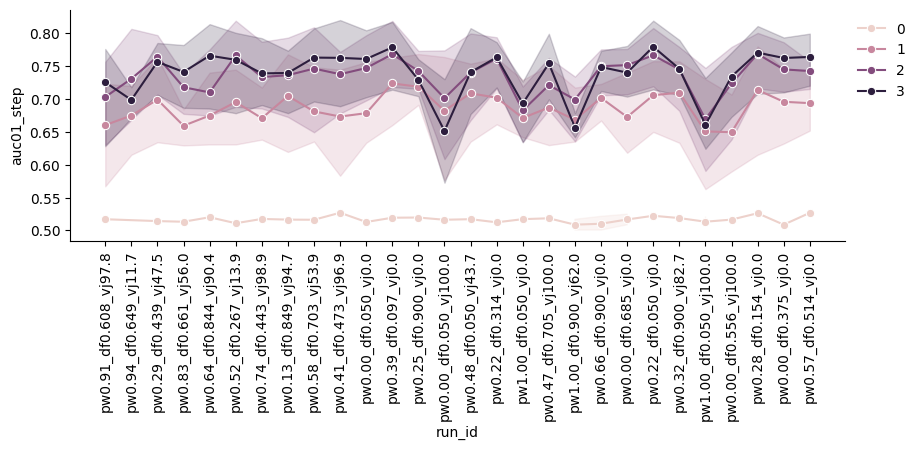

In [14]:
df = pd.read_csv('optimizer_runs_prior/bayes_history.csv')

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='auc01', hue='epitope', ax=ax, marker='o')
sns.lineplot(df, x='run_id', y='mean_auc01', ax=ax, marker='o', color='black')
ax.tick_params(axis='x', rotation=90)

ax.legend(bbox_to_anchor=(1,1), frameon=False, fontsize='small')
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='pssm_weight', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='vj_prior_strength', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()

df_long = df.melt(
    id_vars=['run_id', 'pssm_weight', 'decay_factor', 'mean_auc01', 'epitope', 'auc01'],
    value_vars=['auc01_step0', 'auc01_step1', 'auc01_step2', 'auc01_step3'],
    var_name='step',
    value_name='auc01_step'
)

df_long['step'] = df_long['step'].str.replace('auc01_step', '').astype(int)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df_long, x='run_id', y='auc01_step', hue='step', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
ax.legend(bbox_to_anchor=(1,1), frameon=False)
sns.despine()



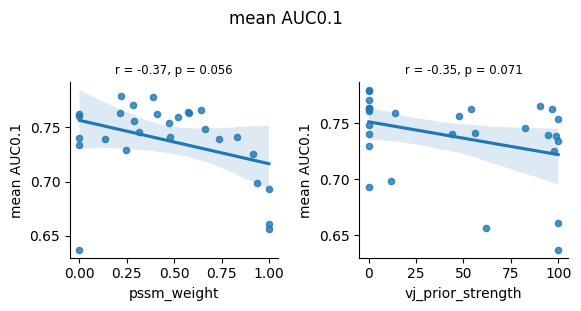

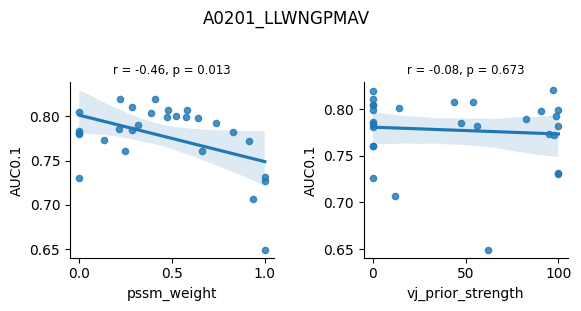

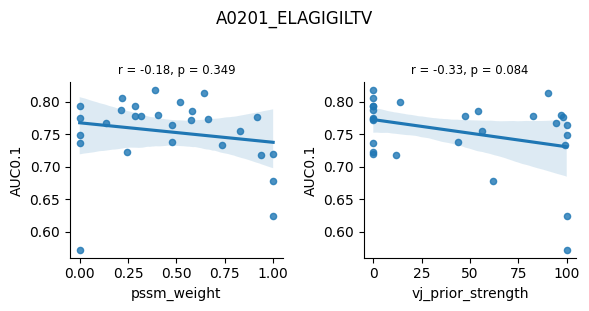

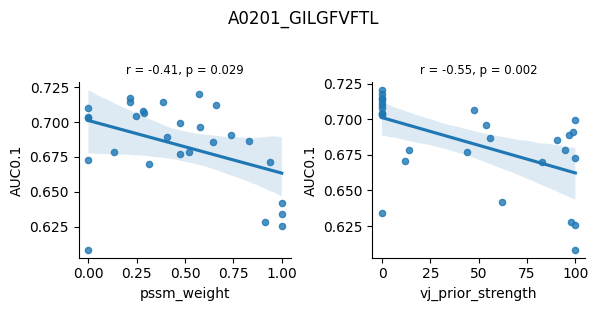

In [19]:
df = pd.read_csv('optimizer_runs_prior/bayes_history.csv')

params = ['pssm_weight', 'vj_prior_strength']
peptides = df['epitope'].unique()

# mean auc01 correlations
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, param in zip(axes, params):
    df_corr = df[['mean_auc01', param]].drop_duplicates()
    r, p = stats.pearsonr(df_corr[param], df_corr['mean_auc01'])
    sns.regplot(df_corr, x=param, y='mean_auc01', ax=ax, scatter_kws={'s': 20})
    ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize='small')
    ax.set_xlabel(param)
    ax.set_ylabel('mean AUC0.1')
plt.suptitle('mean AUC0.1', y=1.02)
plt.tight_layout()
sns.despine()

# per-peptide correlations
for peptide in peptides:
    df_pep = df[df['epitope'] == peptide]
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for ax, param in zip(axes, params):
        r, p = stats.pearsonr(df_pep[param], df_pep['auc01'])
        sns.regplot(df_pep, x=param, y='auc01', ax=ax, scatter_kws={'s': 20})
        ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize='small')
        ax.set_xlabel(param)
        ax.set_ylabel('AUC0.1')
    plt.suptitle(peptide, y=1.02)
    plt.tight_layout()
    sns.despine()

# TEMPO AUC

In [12]:
df = pd.read_csv('grid_search_runs_pssm/grid_results.csv')

agg = (df.groupby(['epitope', 'pssm_weight'])[['auc','auc01']]
    .agg(['mean'])
    .reset_index()
)

agg = agg[agg['pssm_weight'] == 1]
agg

,epitope,pssm_weight,auc,auc01
,,,mean,mean
7,A0201_ELAGIGILTV,1.0,0.922133,0.822105
15,A0201_GILGFVFTL,1.0,0.802719,0.731174
23,A0201_LLWNGPMAV,1.0,0.903096,0.823207


In [ ]:
df = pd.read_csv('grid_search_runs_pssm/grid_results.csv')

agg = (df.groupby(['pssm_weight'])[['auc','auc01']]
    .agg(['mean'])
    .reset_index()
)
agg

,pssm_weight,auc,auc01
,,mean,mean
0,0.3,0.847032,0.765523
1,0.4,0.841771,0.763227
2,0.5,0.856752,0.766540
3,0.6,0.848949,0.769240
4,0.7,0.865451,0.780473
5,0.8,0.860409,0.786575
6,0.9,0.860972,0.783648
7,1.0,0.875982,0.792162


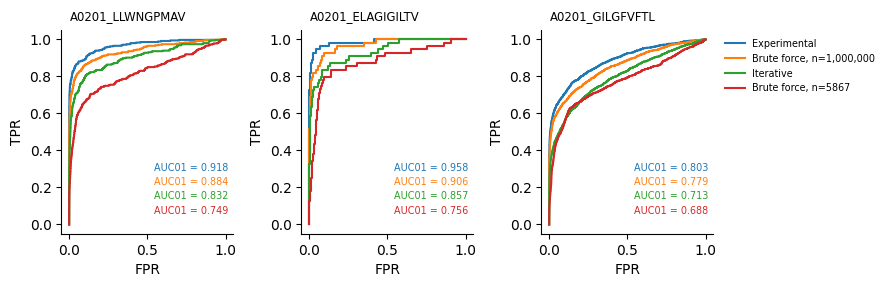

In [13]:
epitopes = ['A0201_LLWNGPMAV', 'A0201_ELAGIGILTV', 'A0201_GILGFVFTL']

sources = {
    'Experimental': lambda p: f'{p}/TEMPO_train_exp.csv',
    'Brute force, n=1,000,000': lambda p: f'brute_force_runs/{p}/validation/validation_pred.csv',
    'Iterative': lambda p: f'test/{p}/validation/validation_pred.csv',
    'Brute force, n=5867': lambda p: f'test/brute_force_runs_small/{p}/validation/validation_pred.csv'
}

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for cnt, epitope in enumerate(epitopes):
    ax = axes[cnt]
    ax.text(0.05, 1.1, epitope, transform=ax.transAxes, va='top', ha='left', fontsize='small')
    for i, (source_name, path_fn) in enumerate(sources.items()):
        df = pd.read_csv(path_fn(epitope))
        y_true, y_scores = df['Label'].values, df['score'].values
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
        line, = ax.plot(fpr, tpr, label=source_name)
        ax.text(0.97, 0.3 - i * 0.07, f"AUC01 = {auc01:.3f}",
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize='x-small', color=line.get_color())

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize='x-small', frameon=False,
                bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()






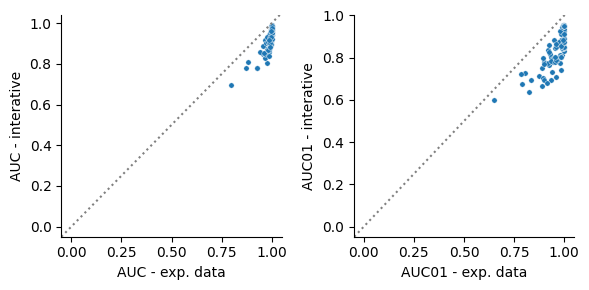

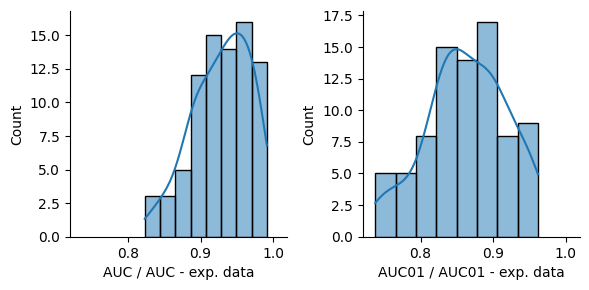

,epitope,auc,auc01,auc_exp,auc01_exp,n_tcrs_exp,ratio_auc,ratio_auc01
36,A0201_RTATKQYNV,0.885346,0.708758,0.992591,0.961003,94,0.891955,0.737519
73,B3501_IPSINVHHY,0.866957,0.681026,0.983831,0.914900,109,0.881205,0.744372
70,B1501_NQKLIANQF,0.838816,0.694461,0.984056,0.931833,87,0.852407,0.745264
44,A0301_KTFPPTEPK,0.830688,0.667629,0.967930,0.887165,187,0.858211,0.752541
2,A0101_FTSDYYQLY,0.896175,0.741132,0.997102,0.984749,45,0.898779,0.752610
18,A0201_CLGGLLTMV,0.803531,0.695646,0.976239,0.901146,156,0.823088,0.771957
59,B0702_SPRWYFYYL,0.781368,0.639032,0.928910,0.823069,721,0.841166,0.776401
0,A0101_ATDALMTGF,0.855815,0.732282,0.985765,0.940750,176,0.868173,0.778403
4,A0101_LTDEMIAQY,0.836031,0.704268,0.970946,0.895138,137,0.861048,0.786770
11,A0101_VTEHDTLLY,0.911948,0.773395,0.995979,0.978837,237,0.915630,0.790116


In [10]:
df1 = pd.read_csv('auc_summary.csv')
df2 = pd.read_csv('auc_summary_exp.csv')
df2 = df2.rename(columns={'auc': 'auc_exp', 'auc01': 'auc01_exp'})

df = pd.merge(df1, df2, on='epitope')

# number of experimental TCRs per epitope
def count_tcrs(epitope):
    path = f'{epitope}/{epitope}.csv'
    try:
        return len(pd.read_csv(path))
    except FileNotFoundError:
        return np.nan

df['n_tcrs_exp'] = df['epitope'].apply(count_tcrs)

# --- Figure 1: scatter plots ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, (x_col, y_col) in zip(axes, [('auc_exp', 'auc'), ('auc01_exp', 'auc01')]):
    sns.scatterplot(df, x=x_col, y=y_col, ax=ax, s=15)
    ax.axline((0, 0), slope=1, color='gray', linestyle=':')
    #ax.set_xlim(0.60, 1.05)
    #ax.set_ylim(0.60, 1.05)

axes[0].set_ylabel('AUC - interative')
axes[0].set_xlabel('AUC - exp. data')
axes[1].set_ylabel('AUC01 - interative')
axes[1].set_xlabel('AUC01 - exp. data')
sns.despine()
plt.tight_layout()
plt.show()

# --- Figure 2: ratio histograms ---
df['ratio_auc']   = df['auc']   / df['auc_exp']
df['ratio_auc01'] = df['auc01'] / df['auc01_exp']

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, col, label in zip(axes,
                           ['ratio_auc', 'ratio_auc01'],
                           ['AUC / AUC_exp', 'AUC01 / AUC01_exp']):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_xlabel(label)

    ax.set_xlim(0.72, 1.02)

axes[0].set_xlabel('AUC / AUC - exp. data')
axes[1].set_xlabel('AUC01 / AUC01 - exp. data')
sns.despine()
plt.tight_layout()
plt.show()

df = df.sort_values(by='ratio_auc01')
df.head(20)


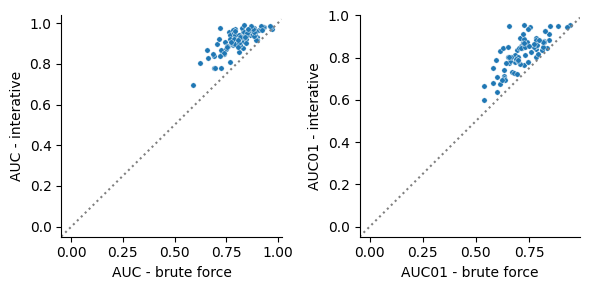

In [8]:
df1 = pd.read_csv('auc_summary.csv')
df2 = pd.read_csv('brute_force_runs_small/auc_summary_brute.csv')
df2 = df2.rename(columns={'auc': 'auc_brute', 'auc01': 'auc01_brute'})

df = pd.merge(df1, df2, on='epitope')

# number of experimental TCRs per epitope
def count_tcrs(epitope):
    path = f'{epitope}/{epitope}.csv'
    try:
        return len(pd.read_csv(path))
    except FileNotFoundError:
        return np.nan

df['n_tcrs_exp'] = df['epitope'].apply(count_tcrs)

# --- Figure 1: scatter plots ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=False, sharey=False)

for ax, (x_col, y_col) in zip(axes, [('auc_brute', 'auc'), ('auc01_brute', 'auc01')]):
    sns.scatterplot(df, x=x_col, y=y_col, ax=ax, s=15)
    ax.axline((0, 0), slope=1, color='gray', linestyle=':')
    #ax.set_xlim(0.50, 1.05)
    #ax.set_ylim(0.50, 1.05)
    
axes[0].set_ylabel('AUC - interative')
axes[0].set_xlabel('AUC - brute force')
axes[1].set_ylabel('AUC01 - interative')
axes[1].set_xlabel('AUC01 - brute force')
sns.despine()
plt.tight_layout()
plt.show()

# IMMREP23 benchmark

In [98]:
# ── Positives ──────────────────────────────────────────────────────────────────
df_pos = pd.read_csv('/Users/roessner/Documents/PostDoc/Data/TCR_data/EpitopeSpecific/'
                     'PublicDatabases/full_dataset_TCR-epitope_clean_study.csv')
df_pos = df_pos[df_pos['study'] == 'IMMREP23'].copy()
df_pos['Label'] = 1

# ── Negatives (repertoire) ─────────────────────────────────────────────────────
df_rep = pd.read_parquet('/Users/roessner/Documents/PostDoc/Data/TCR_data/Repertoires/'
                         'df_sel_studies_ireceptor_pairs_allele_and_NO_allele_merged.parquet')

def sample_negatives(n_total, df_rep, seed=42):
    studies       = df_rep['study_id'].unique()
    n_per_study   = max(1, n_total // len(studies))
    samples       = []
    for study in studies:
        study_df      = df_rep[df_rep['study_id'] == study]
        subjects      = study_df['subject_id'].unique()
        n_per_subject = max(1, n_per_study // len(subjects))
        sampled_study = (
            study_df.groupby('subject_id', group_keys=False)
                    .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
        )
        samples.append(sampled_study)
    sampled = pd.concat(samples)
    return sampled.sample(min(n_total, len(sampled)), random_state=seed)

# ── Build per-epitope validation sets ─────────────────────────────────────────
cols = ['model', 'epitope', 'MHC', 'cdr3_TRA', 'cdr3_TRB', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'study', 'Label']

for epitope, pos_group in df_pos.groupby('model'):
    n_pos = len(pos_group)
    neg   = sample_negatives(n_pos, df_rep).copy()
    neg['Label'] = 0
    neg['model'] = epitope

    val = pd.concat([pos_group, neg], ignore_index=True)
    val = val[cols]

    os.makedirs(f'IMMREP23/{epitope}', exist_ok=True)
    val.to_csv(f'IMMREP23/{epitope}/validation.csv', index=False)
    print(f"{epitope}: {n_pos} pos / {len(neg)} neg")

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var

A0101_FTDALGIDEY: 12 pos / 12 neg
A0101_SALPTNADLY: 18 pos / 18 neg
A0101_TDLGQNLLY: 33 pos / 33 neg
A0101_TSDACMMTMY: 11 pos / 11 neg


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var

A0101_VSDGGPNLY: 58 pos / 58 neg
A0101_VTEHDTLLY: 25 pos / 25 neg
A0201_GILGFVFTL: 103 pos / 103 neg
A0201_GLCTLVAML: 24 pos / 24 neg


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var

...

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var

A1101_IVTDFSVIK: 14 pos / 14 neg
B0702_RPHERNGFTVL: 19 pos / 19 neg
B0702_RPPIFIRRL: 15 pos / 15 neg
B0702_TPRVTGGGAM: 13 pos / 13 neg


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var

B0801_QIKVRVDMV: 16 pos / 16 neg
B0801_RAKFKQLL: 62 pos / 62 neg
B3501_EPLPQGQLTAY: 48 pos / 48 neg
B3501_IPSINVHHY: 16 pos / 16 neg


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/1141583443.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), n_per_subject), random_state=seed))
/var

In [ ]:
df_train = pd.read_csv('All_models_TCRs.csv')

final_epitopes = []
for epitope, train_group in df_train.groupby('model'):
    val_path = f'IMMREP23/{epitope}/validation.csv'
    if not os.path.exists(val_path):
        continue

    val = pd.read_csv(val_path)
    val_pos = val[val['Label'] == 1]

    val_pairs = set(zip(val_pos['cdr3_TRA'], val_pos['cdr3_TRB']))
    mask = ~train_group.apply(lambda r: (r['cdr3_TRA'], r['cdr3_TRB']) in val_pairs, axis=1)
    train_filtered = train_group[mask]

    if len(train_filtered) == 0:
        print(f"{epitope}: no training TCRs left after exclusion — skipping")
        continue

    train_filtered.to_csv(f'IMMREP23/{epitope}/{epitope}.csv', index=False)
    final_epitopes.append(epitope)
    print(f"{epitope}: {len(train_group)} total → {len(train_filtered)} after exclusion")

with open('IMMREP23/epitopes.txt', 'w') as f:
    f.write('\n'.join(final_epitopes))

print(f"\n{len(final_epitopes)} epitopes written to IMMREP23/epitopes.txt")

A0101_TDLGQNLLY: 48 total → 15 after exclusion
A0101_VSDGGPNLY: 83 total → 25 after exclusion
A0101_VTEHDTLLY: 237 total → 212 after exclusion
A0201_GILGFVFTL: 8272 total → 8166 after exclusion
A0201_GLCTLVAML: 1492 total → 1465 after exclusion
A0201_NLVPMVATV: 6937 total → 6890 after exclusion
A0201_VLEETSVML: 46 total → 25 after exclusion
A0201_YLQPRTFLL: 1365 total → 1350 after exclusion
A0201_YVLDHLIVV: 651 total → 617 after exclusion
A1101_IVTDFSVIK: 139 total → 125 after exclusion
B0702_RPHERNGFTVL: 85 total → 66 after exclusion
B0702_RPPIFIRRL: 140 total → 125 after exclusion
B0702_TPRVTGGGAM: 327 total → 314 after exclusion
B0801_QIKVRVDMV: 38 total → 22 after exclusion
B0801_RAKFKQLL: 1093 total → 1031 after exclusion
B3501_EPLPQGQLTAY: 107 total → 57 after exclusion
B3501_IPSINVHHY: 109 total → 93 after exclusion

17 epitopes written to IMMREP23/epitopes.txt


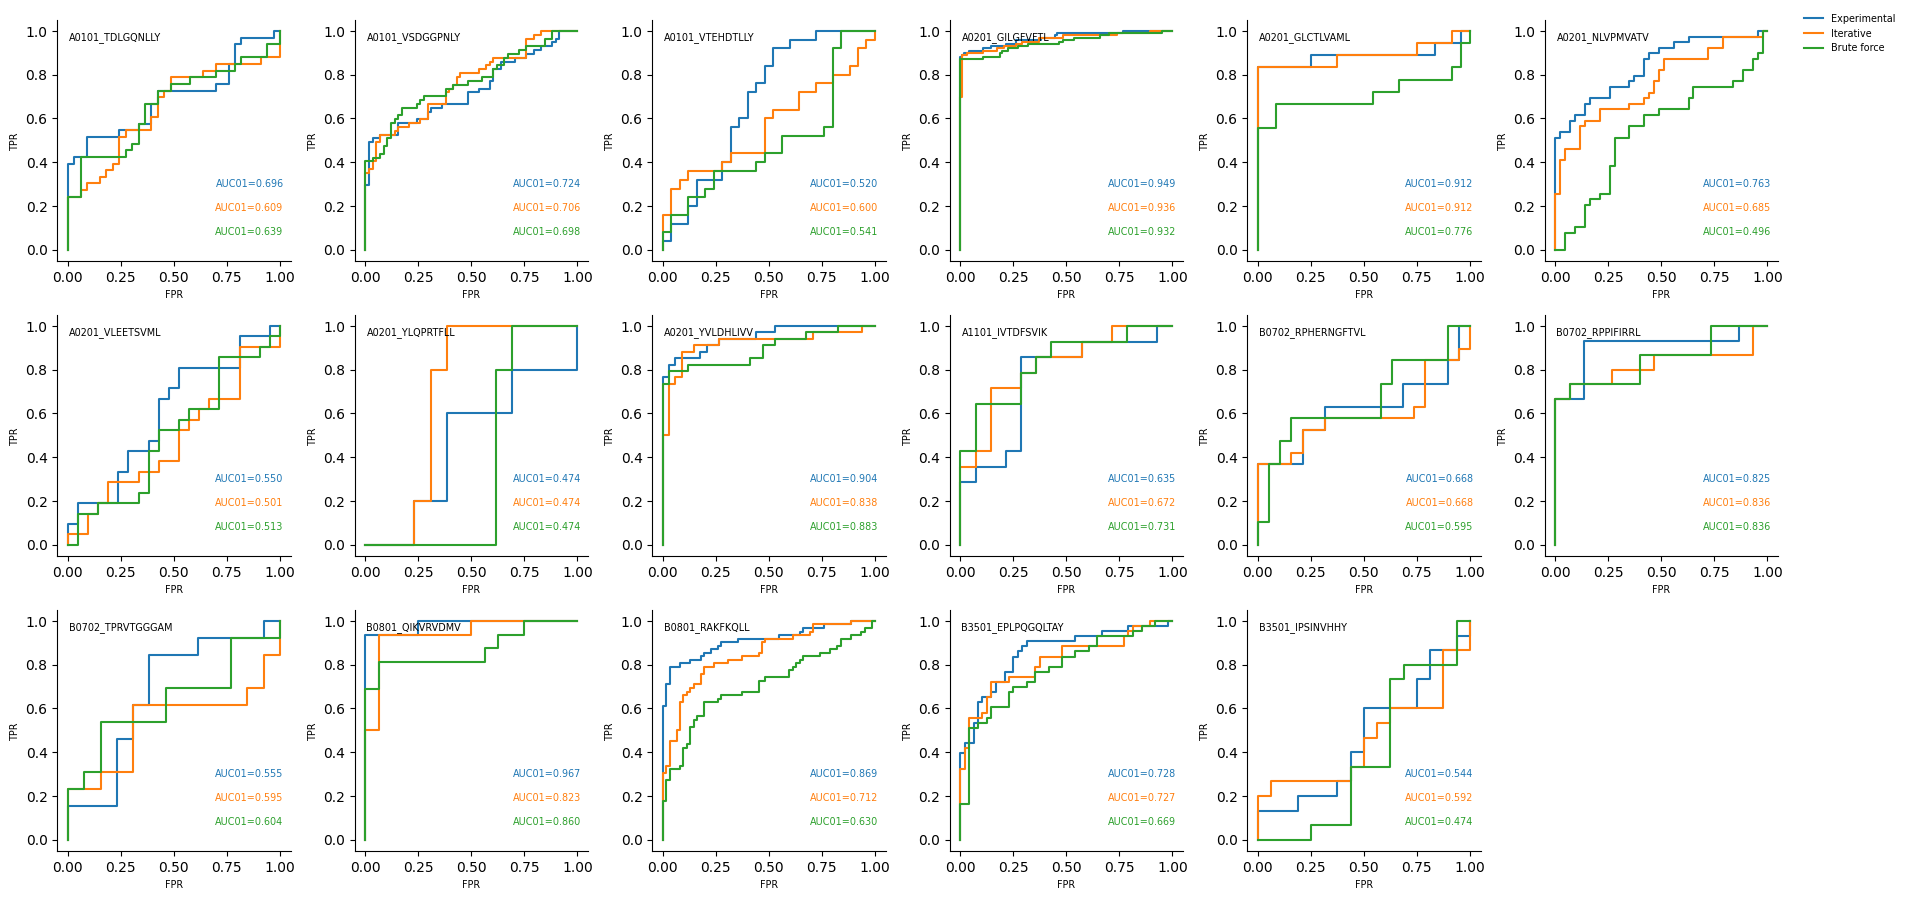

In [12]:
with open('IMMREP23/epitopes.txt') as f:
    epitopes = [line.strip() for line in f if line.strip()]

sources = {
    'Experimental':      lambda p: f'IMMREP23/{p}/TEMPO_train_exp.csv',
    'Iterative':         lambda p: f'IMMREP23/{p}/validation/validation_pred.csv',
    'Brute force':       lambda p: f'IMMREP23/brute_force_runs_small/{p}/validation/validation_pred.csv'
}

n_cols = 6
n_rows = math.ceil(len(epitopes) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

for cnt, epitope in enumerate(epitopes):
    ax = axes[cnt]
    ax.text(0.05, 0.95, epitope, transform=ax.transAxes, va='top', ha='left', fontsize='x-small')
    for i, (source_name, path_fn) in enumerate(sources.items()):
        try:
            df = pd.read_csv(path_fn(epitope))
            y_true, y_scores = df['Label'].values, df['score'].values
            mask = ~np.isnan(y_scores) & ~np.isnan(y_true)
            y_true, y_scores = y_true[mask], y_scores[mask]
            if len(np.unique(y_true)) < 2:
                continue
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
            line, = ax.plot(fpr, tpr, label=source_name)
            ax.text(0.97, 0.3 - i * 0.1, f"AUC01={auc01:.3f}",
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize='x-small', color=line.get_color())
        except FileNotFoundError:
            pass
    ax.set_xlabel('FPR', fontsize='x-small')
    ax.set_ylabel('TPR', fontsize='x-small')

for ax in axes[len(epitopes):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize='x-small', frameon=False,
           bbox_to_anchor=(1.0, 1.0), loc='upper left')

sns.despine()
plt.tight_layout()

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_97899/780271137.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize='x-small')


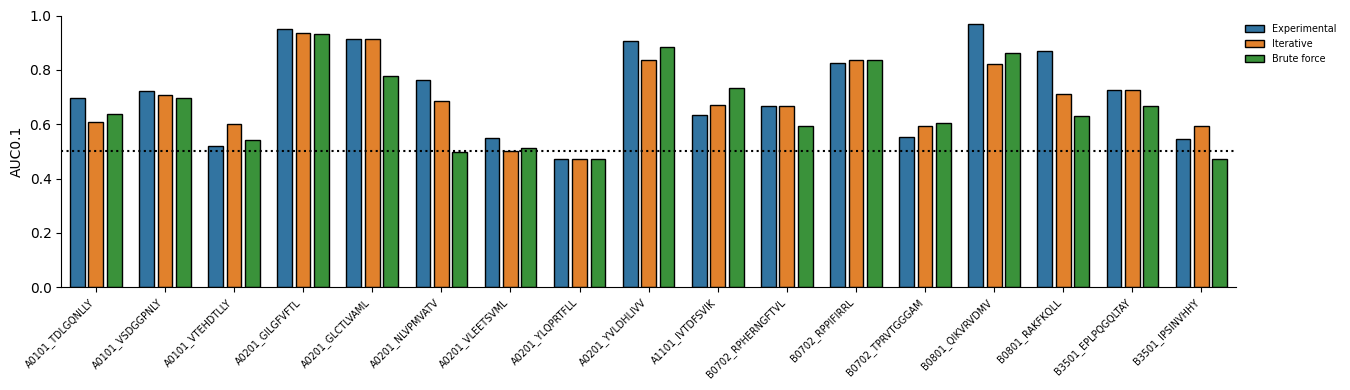

In [116]:
records = []
with open('IMMREP23/epitopes.txt') as f:
    epitopes = [line.strip() for line in f if line.strip()]

sources = {
    'Experimental':  lambda p: f'IMMREP23/{p}/TEMPO_train_exp.csv',
    'Iterative':     lambda p: f'IMMREP23/{p}/validation/validation_pred.csv',
    'Brute force':   lambda p: f'IMMREP23/brute_force_runs_small/{p}/validation/validation_pred.csv'
}

for epitope in epitopes:
    for source_name, path_fn in sources.items():
        try:
            df = pd.read_csv(path_fn(epitope))
            y_true, y_scores = df['Label'].values, df['score'].values
            mask = ~np.isnan(y_scores) & ~np.isnan(y_true)
            y_true, y_scores = y_true[mask], y_scores[mask]
            if len(np.unique(y_true)) < 2:
                auc01 = np.nan
            else:
                try:
                    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
                except ValueError:
                    auc01 = np.nan
        except FileNotFoundError:
            auc01 = np.nan
        records.append({'epitope': epitope, 'source': source_name, 'auc01': auc01})

df_summary = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(len(epitopes) * 0.8, 4))
sns.barplot(df_summary, x='epitope', y='auc01', hue='source', ax=ax, gap=0.2, edgecolor='black')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize='x-small')
ax.set_ylabel('AUC0.1')
ax.set_xlabel('')
ax.legend(fontsize='x-small', frameon=False, bbox_to_anchor=(1, 1), loc='upper left')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='black', linestyle=':')
sns.despine()
plt.tight_layout()

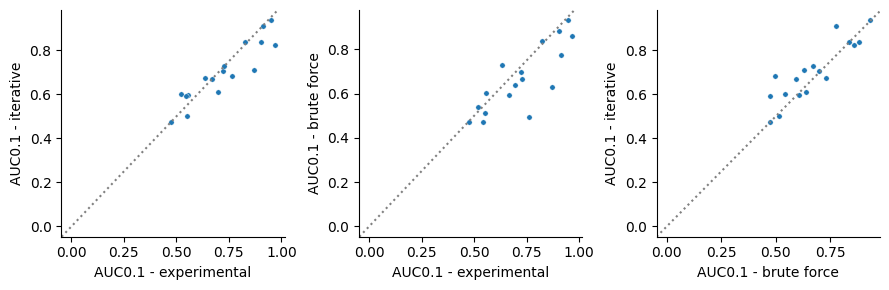

In [19]:
records = []
with open('IMMREP23/epitopes.txt') as f:
    epitopes = [line.strip() for line in f if line.strip()]

sources = {
    'Experimental':  lambda p: f'IMMREP23/{p}/TEMPO_train_exp.csv',
    'Iterative':     lambda p: f'IMMREP23/{p}/validation/validation_pred.csv',
    'Brute force':   lambda p: f'IMMREP23/brute_force_runs_small/{p}/validation/validation_pred.csv'
}

# Load AUC0.1 scores for all epitopes and sources
for epitope in epitopes:
    row = {'epitope': epitope}
    for source_name, path_fn in sources.items():
        try:
            df = pd.read_csv(path_fn(epitope))
            y_true, y_scores = df['Label'].values, df['score'].values
            mask = ~np.isnan(y_scores) & ~np.isnan(y_true)
            y_true, y_scores = y_true[mask], y_scores[mask]
            if len(np.unique(y_true)) < 2:
                auc01 = np.nan
            else:
                try:
                    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
                except ValueError:
                    auc01 = np.nan
        except FileNotFoundError:
            auc01 = np.nan
        row[source_name] = auc01
    records.append(row)

df = pd.DataFrame(records)

# --- Scatter plots: AUC0.1 comparisons ---
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=False, sharey=False)

# Left: Experimental vs Iterative
sns.scatterplot(df, x='Experimental', y='Iterative', ax=axes[0], s=15)
axes[0].axline((0, 0), slope=1, color='gray', linestyle=':')
axes[0].set_xlabel('AUC0.1 - experimental')
axes[0].set_ylabel('AUC0.1 - iterative')


# Middle: Experimental vs Brute force
sns.scatterplot(df, x='Experimental', y='Brute force', ax=axes[1], s=15)
axes[1].axline((0, 0), slope=1, color='gray', linestyle=':')
axes[1].set_xlabel('AUC0.1 - experimental')
axes[1].set_ylabel('AUC0.1 - brute force')


# Right: Brute force vs Iterative
sns.scatterplot(df, x='Brute force', y='Iterative', ax=axes[2], s=15)
axes[2].axline((0, 0), slope=1, color='gray', linestyle=':')
axes[2].set_xlabel('AUC0.1 - brute force')
axes[2].set_ylabel('AUC0.1 - iterative')


sns.despine()
plt.tight_layout()
plt.show()

# Optimize number of TCRs to score 

   vj_prior_strength     auc01
2                 20  0.777832
0                  0  0.773376
1                  5  0.768960
3                 50  0.760056
4                100  0.731963


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_43394/890307188.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(df, x='vj_prior_strength', y='auc01', ax=ax, marker='o', color='black', ci=False)


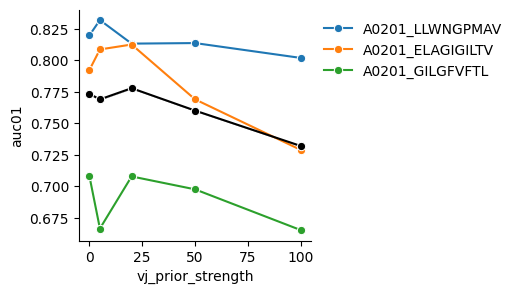

In [37]:
df = pd.read_csv('grid_search_runs_prior/grid_results.csv')

fig, ax = plt.subplots(1, 1, figsize=(3, 3), sharey=True)


sns.lineplot(df, x='vj_prior_strength', y='auc01', hue='epitope', ax=ax, marker='o')
sns.lineplot(df, x='vj_prior_strength', y='auc01', ax=ax, marker='o', color='black', ci=False)
ax.legend(bbox_to_anchor=(1,1), frameon=False)
sns.despine()

df = df.groupby('vj_prior_strength', as_index=False)['auc01'].mean()
df = df.sort_values(by='auc01', ascending=False)
print(df)


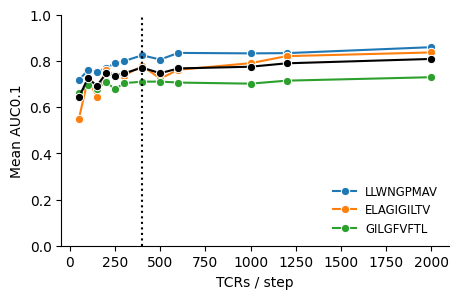

In [36]:
df['tcrs_per_step'] = df['n_pairs'] * df['n_cdr3_multi']
mean_df = df.groupby('tcrs_per_step')['auc01'].mean().reset_index()

fig, ax = plt.subplots(figsize=(5, 3))
sns.lineplot(mean_df, x='tcrs_per_step', y='auc01', marker='o', ax=ax, color='black', zorder=3)
sns.lineplot(df, x='tcrs_per_step', y='auc01', hue='peptide', marker='o', ax=ax)
ax.set_xlabel('TCRs / step')
ax.set_ylabel('Mean AUC0.1')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', frameon=False, fontsize='small')
sns.despine()
ax.axvline(x=400, linestyle=':', color='black')

In [22]:
df = pd.read_csv('A0201_GLCTLVAML/step3/top_tcrs.csv')

pairs_of_interest = [
    ('TRAV5',    'TRBV29-1'), # experimentally observed
    ('TRAV12-2', 'TRBV2'), # experimentally observed
    ('TRAV5',    'TRBV2'),
    ('TRAV12',   'TRBV29-1'),
]

results = pd.DataFrame(pairs_of_interest, columns=['TRAV', 'TRBV'])
results['count'] = results.apply(
    lambda row: ((df['TRAV'] == row['TRAV']) & (df['TRBV'] == row['TRBV'])).sum(),
    axis=1
)
print(results)

       TRAV      TRBV  count
0     TRAV5  TRBV29-1    129
1  TRAV12-2     TRBV2      0
2     TRAV5     TRBV2      0
3    TRAV12  TRBV29-1      0
